In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [80]:
dataset = load_digits()
X = np.array(dataset["data"])
y = np.array(dataset["target"])
print(dataset.keys())
print(X.shape)
print(X.max())
print(X.std())
print(X[0])
print(y.max())
print(y.shape)

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64)
16.0
6.016787548672236
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
9
(1797,)


In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.2)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1437, 64) (360, 64) (1437,) (360,)


In [82]:
results = []
def evaluate_classifier(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = (y_pred == y_test).mean()
    results.append({"name": name, "accuracy": acc})

    print(f"{name} accuracy: {acc:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=dataset.target_names,
        cmap="Blues",
        values_format="d"
    )
    plt.title(f"{name} confusion matrix")
    plt.show()

    return y_pred

logistic_regression accuracy: 0.9722


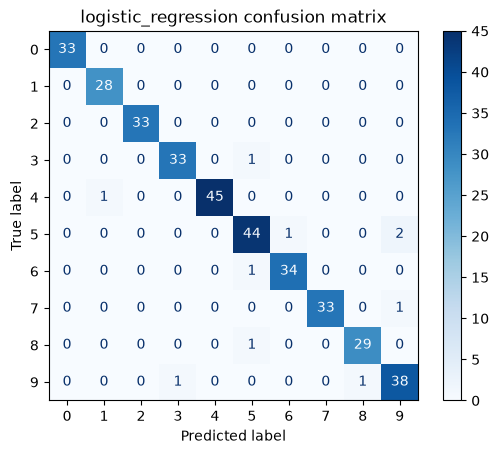

In [83]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=3000))
])

evaluate_classifier(model, "logistic_regression");